# Scratch + Embedding TFLite Model Evaluation

이 노트북은 `direct` baseline, `data/models/scratch/`의 scratch TFLite 모델, `data/models/embedding/`의 fine-tuned embedding TFLite 모델을 같은 지표로 비교한다.

## 평가 지표

| 지표 | 측정 대상 | 좋은 값 |
|---|---|---|
| **1. Pair discrimination** | 같은 동작은 cos↑, 다른 동작은 cos↓ | `gap ↑`, `AUC ↑` |
| **2. Temporal smoothness** | 연속된 프레임의 embedding이 매끈하게 흐르는가 | `cos(E(t), E(t+k))` 가 k에 따라 매끈 감소 |
| **3. Noise robustness** | MediaPipe jitter를 모사한 Gaussian noise에서 embedding이 안정적인가 | σ가 커져도 `cos(E_clean, E_noisy)` 가 높게 유지 |
| **4. Top-1 retrieval** | 5개 춤 중 정답 춤이 1위인 비율 | 높을수록 좋음 |

모든 method는 `window: (T, J, C) -> l2-normalized embedding` 계약으로 평가된다. `direct_frame`, `direct_window`도 같은 인터페이스로 감싸서 모델들과 비교한다.

모델 이름은 충돌을 피하기 위해 `scratch::{model_name}`, `embedding::{model_name}` 형식으로 표시한다.


## 0. 환경 설정

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import matplotlib.pyplot as plt

start = Path.cwd().resolve()
candidates = [start, *start.parents]
for base in [start, *start.parents]:
    candidates.extend([
        base / 'boot_env' / 'pjt_main',
        base / 'pjt_main',
    ])

PROJECT_ROOT = None
for candidate in candidates:
    if (candidate / 'scripts' / 'train_scratch_similarity.py').exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise RuntimeError('pjt_main project root를 찾지 못했습니다.')

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import tensorflow as tf
from pose.landmark_utils import DANCE_JOINTS
from scoring.scratch_features import build_pose_window, normalize_pose_landmarks

SCRATCH_MODELS_DIR = PROJECT_ROOT / 'data' / 'models' / 'scratch'
EMBEDDING_MODELS_DIR = PROJECT_ROOT / 'data' / 'models' / 'embedding'
REFERENCES_DIR = PROJECT_ROOT / 'data' / 'reference_dances'

print(f'PROJECT_ROOT         = {PROJECT_ROOT}')
print(f'SCRATCH_MODELS_DIR   = {SCRATCH_MODELS_DIR}')
print(f'EMBEDDING_MODELS_DIR = {EMBEDDING_MODELS_DIR}')
print(f'TensorFlow           = {tf.__version__}')


2026-04-16 10:50:29.296198: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-16 10:50:29.311041: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-16 10:50:29.311065: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-16 10:50:29.321297: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-16 10:50:29.868735: W tensorflow/compiler/tf

PROJECT_ROOT         = /workspace/users/yijin/boot_env/pjt_main
SCRATCH_MODELS_DIR   = /workspace/users/yijin/boot_env/pjt_main/data/models/scratch
EMBEDDING_MODELS_DIR = /workspace/users/yijin/boot_env/pjt_main/data/models/embedding
TensorFlow           = 2.16.2


## 1. 평가 파라미터

각 지표의 sample 수, stride, window sigma 등을 한곳에 모아둔다. 아래 값들은 실행 시간 10~60초 정도를 타겟한 기본값. 모델이 많아지면 `n_pairs_per_dance`, `smoothness_segment_length`, `n_noise_windows` 를 줄이면 됨.

In [2]:
EVAL = {
    # 데이터 split
    'train_ratio':      0.7,       # 앞 70% gallery/train-like, 뒤 30% held-out eval
    'default_seq_len':  30,        # meta.json에서 못 읽을 때 fallback
    'default_feat_dims': 2,
    'seed':             42,

    # [지표 1] Pair discrimination
    'positive_jitter':  6,
    'negative_gap':     600,
    'n_pairs_per_dance': 80,       # 각 타입(pos/neg/hard_neg)별

    # [지표 2] Temporal smoothness
    'smoothness_segment_length': 300,
    'smoothness_ks':    [1, 5, 15, 30, 60, 120],

    # [지표 3] Noise robustness
    'n_noise_windows':  60,
    'noise_sigmas':     [0.01, 0.03, 0.05, 0.1],

    # [지표 4] Top-1 retrieval
    'retrieval_query_stride':   15,
    'retrieval_gallery_stride': 6,


    # [지표 5] 서비스 지향 평가: 시간 위치/딜레이/캘리브레이션
    'localization_query_stride': 15,
    'localization_gallery_stride': 3,
    'localization_tolerance_frames': [3, 6, 15, 30],
    'delay_tolerance_frames': [0, 3, 6, 15, 30, 45, 60],
    'delay_top_k': 3,
    'jitter_frames': [0, 3, 6, 15, 30, 60, 120],

    # 비교 대상 포함 여부
    'include_direct_frame':   True,
    'include_direct_window':  True,
    'include_scratch_models': True,
    'include_embedding_models': True,
}

rng = np.random.default_rng(EVAL['seed'])
print(json.dumps(EVAL, indent=2))


{
  "train_ratio": 0.7,
  "default_seq_len": 30,
  "default_feat_dims": 2,
  "seed": 42,
  "positive_jitter": 6,
  "negative_gap": 600,
  "n_pairs_per_dance": 80,
  "smoothness_segment_length": 300,
  "smoothness_ks": [
    1,
    5,
    15,
    30,
    60,
    120
  ],
  "n_noise_windows": 60,
  "noise_sigmas": [
    0.01,
    0.03,
    0.05,
    0.1
  ],
  "retrieval_query_stride": 15,
  "retrieval_gallery_stride": 6,
  "localization_query_stride": 15,
  "localization_gallery_stride": 3,
  "localization_tolerance_frames": [
    3,
    6,
    15,
    30
  ],
  "delay_tolerance_frames": [
    0,
    3,
    6,
    15,
    30,
    45,
    60
  ],
  "delay_top_k": 3,
  "jitter_frames": [
    0,
    3,
    6,
    15,
    30,
    60,
    120
  ],
  "include_direct_frame": true,
  "include_direct_window": true,
  "include_scratch_models": true,
  "include_embedding_models": true
}


## 2. Reference 데이터 로딩

In [3]:
references = {}
for d in sorted(REFERENCES_DIR.iterdir()):
    npy = d / 'reference.npy'
    if not npy.exists():
        continue
    seq = np.load(npy).astype(np.float32)
    if seq.ndim != 3 or seq.shape[1] < 29:
        print(f'[SKIP] {d.name}: invalid shape {seq.shape}')
        continue
    if seq.shape[2] == 3:
        vis = np.ones((*seq.shape[:2], 1), dtype=np.float32)
        seq = np.concatenate([seq, vis], axis=2)
    seq = np.nan_to_num(seq)
    references[d.name] = seq
    split_idx = int(len(seq) * EVAL['train_ratio'])
    print(f'  {d.name:16s} frames={len(seq):5d}  '
          f'gallery=[0, {split_idx}), eval=[{split_idx}, {len(seq)})')

assert references, 'reference.npy 파일이 필요합니다.'

  beginner_wave    frames= 1800  gallery=[0, 1260), eval=[1260, 1800)
  cheerup_dance    frames=  724  gallery=[0, 506), eval=[506, 724)
  freestyle_free   frames= 3600  gallery=[0, 2520), eval=[2520, 3600)
  hiphop_move      frames=  792  gallery=[0, 554), eval=[554, 792)
  kpop_basic       frames= 2700  gallery=[0, 1889), eval=[1889, 2700)


## 3. 모델 발견 + 공통 embedder 인터페이스

`SCRATCH_MODELS_DIR`와 `EMBEDDING_MODELS_DIR`에서 `.tflite`를 모두 스캔한다. Scratch 모델과 fine-tuned embedding 모델은 모두 같은 TFLite encoder 계약을 가진다.

```text
window: (T, J, C) -> embedding vector -> l2 normalize
```

Direct baseline도 같은 인터페이스로 감싸서 이후 지표 계산 코드를 그대로 공유한다.


In [4]:
def l2norm(v, eps=1e-8):
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return v / np.maximum(n, eps)


def make_interpreter(tflite_path):
    interp = tf.lite.Interpreter(model_path=str(tflite_path))
    interp.allocate_tensors()
    return interp


def _tflite_embed(interp, window):
    in_det = interp.get_input_details()[0]
    out_det = interp.get_output_details()[0]
    tensor = window[None, ...].astype(np.float32)
    if not np.issubdtype(in_det['dtype'], np.floating):
        scale, zero = in_det.get('quantization', (0.0, 0))
        if scale:
            q = np.round(tensor / scale + zero)
            info = np.iinfo(in_det['dtype'])
            tensor = np.clip(q, info.min, info.max).astype(in_det['dtype'])
    interp.set_tensor(in_det['index'], tensor)
    interp.invoke()
    out = interp.get_tensor(out_det['index'])
    if not np.issubdtype(out.dtype, np.floating):
        scale, zero = out_det.get('quantization', (0.0, 0))
        if scale:
            out = (out.astype(np.float32) - zero) * scale
    return out.reshape(-1).astype(np.float32)


def config_from_meta(meta):
    cfg = dict(meta.get('config', {}) or {})
    encoder_cfg = meta.get('encoder_config', {}) or {}
    for key in ('sequence_length', 'feature_dims', 'embedding_dim'):
        if key not in cfg and key in encoder_cfg:
            cfg[key] = encoder_cfg[key]
    return cfg


def add_tflite_methods(methods, models_dir, family):
    if not models_dir.exists():
        print(f'[WARN] {family} dir not found: {models_dir}')
        return
    for tflite_path in sorted(models_dir.glob('*.tflite')):
        meta_path = tflite_path.with_name(f'{tflite_path.stem}_meta.json')
        meta = json.loads(meta_path.read_text('utf-8')) if meta_path.exists() else {}
        cfg = config_from_meta(meta)
        interp = make_interpreter(tflite_path)
        methods.append({
            'name':      f'{family}::{tflite_path.stem}',
            'family':    family,
            'raw_name':  tflite_path.stem,
            'loss':      cfg.get('loss_type', '-'),
            'seq_len':   int(cfg.get('sequence_length', EVAL['default_seq_len'])),
            'feat_dims': int(cfg.get('feature_dims', EVAL['default_feat_dims'])),
            'meta':      meta,
            'path':      tflite_path,
            'embed':     (lambda w, interp=interp: l2norm(_tflite_embed(interp, w))),
        })


methods = []

if EVAL['include_direct_frame']:
    methods.append({
        'name':     'direct_frame',
        'family':   'direct',
        'loss':     '-',
        'seq_len':  EVAL['default_seq_len'],
        'feat_dims': EVAL['default_feat_dims'],
        'embed':    lambda w: l2norm(w[-1].flatten()),
    })
if EVAL['include_direct_window']:
    methods.append({
        'name':     'direct_window',
        'family':   'direct',
        'loss':     '-',
        'seq_len':  EVAL['default_seq_len'],
        'feat_dims': EVAL['default_feat_dims'],
        'embed':    lambda w: l2norm(w.flatten()),
    })

if EVAL['include_scratch_models']:
    add_tflite_methods(methods, SCRATCH_MODELS_DIR, 'scratch')
if EVAL['include_embedding_models']:
    add_tflite_methods(methods, EMBEDDING_MODELS_DIR, 'embedding')

print(f'총 {len(methods)}개 method 준비됨:')
for m in methods:
    print(f'  {m["name"]:45s} family={m["family"]:9s} loss={m["loss"]:8s} '
          f'seq_len={m["seq_len"]} feat_dims={m.get("feat_dims", EVAL["default_feat_dims"])}')

assert len(methods) > 0, '평가할 method가 없습니다.'


총 14개 method 준비됨:
  direct_frame                                  family=direct    loss=-        seq_len=30 feat_dims=2
  direct_window                                 family=direct    loss=-        seq_len=30 feat_dims=2
  scratch::my_gcn_e32_bce                       family=scratch   loss=bce      seq_len=30 feat_dims=2
  scratch::my_gcn_e32_triplet                   family=scratch   loss=triplet  seq_len=30 feat_dims=2
  scratch::my_gcn_e64_bce                       family=scratch   loss=bce      seq_len=30 feat_dims=2
  scratch::my_gcn_e64_triplet                   family=scratch   loss=triplet  seq_len=30 feat_dims=2
  scratch::my_tcn_e32_bce                       family=scratch   loss=bce      seq_len=30 feat_dims=2
  scratch::my_tcn_e32_triplet                   family=scratch   loss=triplet  seq_len=30 feat_dims=2
  scratch::my_tcn_e64_bce                       family=scratch   loss=bce      seq_len=30 feat_dims=2
  scratch::my_tcn_e64_triplet                   family=scratch  

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## 4. Window 추출 Helper

여러 지표가 같은 held-out 범위에서 window를 요구한다. `valid_eval_end_range` 는 "window가 완전히 held-out 구간 안에 들어가도록" end_idx 범위를 돌려준다.

In [5]:
def valid_eval_end_range(dance_name, seq_length):
    seq = references[dance_name]
    split = int(len(seq) * EVAL['train_ratio'])
    lo = max(split + seq_length - 1, seq_length - 1)
    hi = len(seq) - 1
    if lo > hi:
        return None
    return lo, hi


def make_window(dance_name, end_idx, seq_length, feature_dims):
    return build_pose_window(
        references[dance_name], end_idx, seq_length,
        target_joints=DANCE_JOINTS, feature_dims=feature_dims,
    )


# Sanity check
for d in references:
    er30 = valid_eval_end_range(d, 30)
    print(f'  {d:16s}  eval end 범위 (seq_len=30) = {er30}')

  beginner_wave     eval end 범위 (seq_len=30) = (1289, 1799)
  cheerup_dance     eval end 범위 (seq_len=30) = (535, 723)
  freestyle_free    eval end 범위 (seq_len=30) = (2549, 3599)
  hiphop_move       eval end 범위 (seq_len=30) = (583, 791)
  kpop_basic        eval end 범위 (seq_len=30) = (1918, 2699)


## 5. 지표 1 — Pair Discrimination

**무엇을 보나**: 학습이 강제한 pairwise metric이 held-out에서도 유지되는가.

- **positive**: 같은 춤의 `±positive_jitter` 프레임 이내 두 window (진짜 "같은 동작")
- **negative**: 서로 다른 춤의 임의 window (확실한 "다른 동작")
- **hard_negative**: 같은 춤이지만 `≥negative_gap` 프레임 떨어짐 (같은 style / 다른 동작)

**기대 값**:
- `mean_pos` ↑ (1에 가까움), `mean_neg` ↓ (음수 or 0 근처), `mean_hard_neg` 는 중간
- **`gap = mean_pos - mean_neg`**: 클수록 discriminative
- **`AUC`**: pos vs neg를 cosine으로 분류했을 때 ROC AUC. 1.0이면 완벽 분리

In [6]:
# --- Pair sampling (seq_length는 method마다 다를 수 있으므로 method별로 샘플링) ---
def sample_pairs(seq_length):
    dances = list(references.keys())
    positive, negative, hard_negative = [], [], []

    for d in dances:
        er = valid_eval_end_range(d, seq_length)
        if er is None:
            continue
        lo, hi = er
        for _ in range(EVAL['n_pairs_per_dance']):
            end_a = int(rng.integers(lo, hi + 1))
            delta = int(rng.integers(-EVAL['positive_jitter'], EVAL['positive_jitter'] + 1))
            end_b = int(np.clip(end_a + delta, lo, hi))
            positive.append((d, end_a, d, end_b))

    for _ in range(len(dances) * EVAL['n_pairs_per_dance']):
        d_a, d_b = rng.choice(dances, size=2, replace=False)
        er_a = valid_eval_end_range(d_a, seq_length)
        er_b = valid_eval_end_range(d_b, seq_length)
        if er_a is None or er_b is None:
            continue
        end_a = int(rng.integers(er_a[0], er_a[1] + 1))
        end_b = int(rng.integers(er_b[0], er_b[1] + 1))
        negative.append((d_a, end_a, d_b, end_b))

    for d in dances:
        er = valid_eval_end_range(d, seq_length)
        if er is None:
            continue
        lo, hi = er
        for _ in range(EVAL['n_pairs_per_dance']):
            end_a = int(rng.integers(lo, hi + 1))
            for _ in range(20):
                end_b = int(rng.integers(lo, hi + 1))
                if abs(end_a - end_b) >= EVAL['negative_gap']:
                    break
            hard_negative.append((d, end_a, d, end_b))

    return positive, negative, hard_negative


def compute_pair_cosines(method, pairs):
    seq_length = method['seq_len']
    feat_dims = method.get('feat_dims', EVAL['default_feat_dims'])
    cache = {}

    def get_emb(dance, end):
        key = (dance, end)
        if key not in cache:
            w = make_window(dance, end, seq_length, feat_dims)
            cache[key] = method['embed'](w)
        return cache[key]

    cos_list = []
    for d_a, end_a, d_b, end_b in pairs:
        e_a = get_emb(d_a, end_a)
        e_b = get_emb(d_b, end_b)
        cos_list.append(float(np.dot(e_a, e_b)))
    return np.array(cos_list, dtype=np.float32)


def roc_auc_numpy(pos_scores, neg_scores):
    """sklearn 없이 numpy로 ROC AUC 계산 (Mann-Whitney U / trapz 방식)."""
    y_true  = np.concatenate([np.ones(len(pos_scores)), np.zeros(len(neg_scores))])
    y_score = np.concatenate([pos_scores, neg_scores])
    order   = np.argsort(y_score)[::-1]
    y_sorted = y_true[order]
    n_pos = y_sorted.sum()
    n_neg = len(y_sorted) - n_pos
    if n_pos == 0 or n_neg == 0:
        return float('nan')
    tpr = np.concatenate([[0.0], np.cumsum(y_sorted)     / n_pos])
    fpr = np.concatenate([[0.0], np.cumsum(1 - y_sorted) / n_neg])
    return float(np.trapz(tpr, fpr))


try:
    from sklearn.metrics import roc_auc_score as _sklearn_auc
    def compute_auc(pos_cos, neg_cos):
        labels = np.concatenate([np.ones(len(pos_cos)), np.zeros(len(neg_cos))])
        scores = np.concatenate([pos_cos, neg_cos])
        return float(_sklearn_auc(labels, scores))
    print('[AUC] sklearn 사용')
except ImportError:
    def compute_auc(pos_cos, neg_cos):
        return roc_auc_numpy(pos_cos, neg_cos)
    print('[AUC] sklearn 없음 → numpy fallback 사용')


# --- 실행: 모든 method에 대해 세 pair 타입의 cosine 수집 ---
results_pair = {}
for method in methods:
    # seed는 method마다 같은 pair를 쓰도록 고정
    rng = np.random.default_rng(EVAL['seed'])
    pos_pairs, neg_pairs, hneg_pairs = sample_pairs(method['seq_len'])
    pos_cos = compute_pair_cosines(method, pos_pairs)
    neg_cos = compute_pair_cosines(method, neg_pairs)
    hneg_cos = compute_pair_cosines(method, hneg_pairs)
    gap = float(pos_cos.mean() - neg_cos.mean())
    auc = compute_auc(pos_cos, neg_cos)
    results_pair[method['name']] = {
        'pos': pos_cos, 'neg': neg_cos, 'hneg': hneg_cos,
        'mean_pos': float(pos_cos.mean()),
        'mean_neg': float(neg_cos.mean()),
        'mean_hneg': float(hneg_cos.mean()),
        'gap': gap,
        'auc': auc,
    }
    auc_str = f'{auc:.3f}' if np.isfinite(auc) else '  -  '
    print(f'  {method["name"]:30s}  pos={pos_cos.mean():+.3f}  '
          f'neg={neg_cos.mean():+.3f}  hneg={hneg_cos.mean():+.3f}  '
          f'gap={gap:+.3f}  auc={auc_str}')


[AUC] sklearn 없음 → numpy fallback 사용
  direct_frame                    pos=+0.387  neg=+0.060  hneg=+0.309  gap=+0.328  auc=0.674
  direct_window                   pos=+0.407  neg=+0.069  hneg=+0.294  gap=+0.337  auc=0.690
  scratch::my_gcn_e32_bce         pos=+0.917  neg=-0.034  hneg=+0.337  gap=+0.950  auc=0.986
  scratch::my_gcn_e32_triplet     pos=+0.951  neg=+0.059  hneg=+0.410  gap=+0.891  auc=0.996
  scratch::my_gcn_e64_bce         pos=+0.902  neg=-0.036  hneg=+0.286  gap=+0.938  auc=0.983
  scratch::my_gcn_e64_triplet     pos=+0.960  neg=+0.327  hneg=+0.534  gap=+0.632  auc=0.990
  scratch::my_tcn_e32_bce         pos=+0.930  neg=-0.002  hneg=+0.334  gap=+0.932  auc=0.985
  scratch::my_tcn_e32_triplet     pos=+0.942  neg=+0.030  hneg=+0.378  gap=+0.912  auc=0.994
  scratch::my_tcn_e64_bce         pos=+0.918  neg=-0.072  hneg=+0.306  gap=+0.990  auc=0.990
  scratch::my_tcn_e64_triplet     pos=+0.948  neg=+0.101  hneg=+0.477  gap=+0.847  auc=0.993
  embedding::embedding_gcn_e32_tr

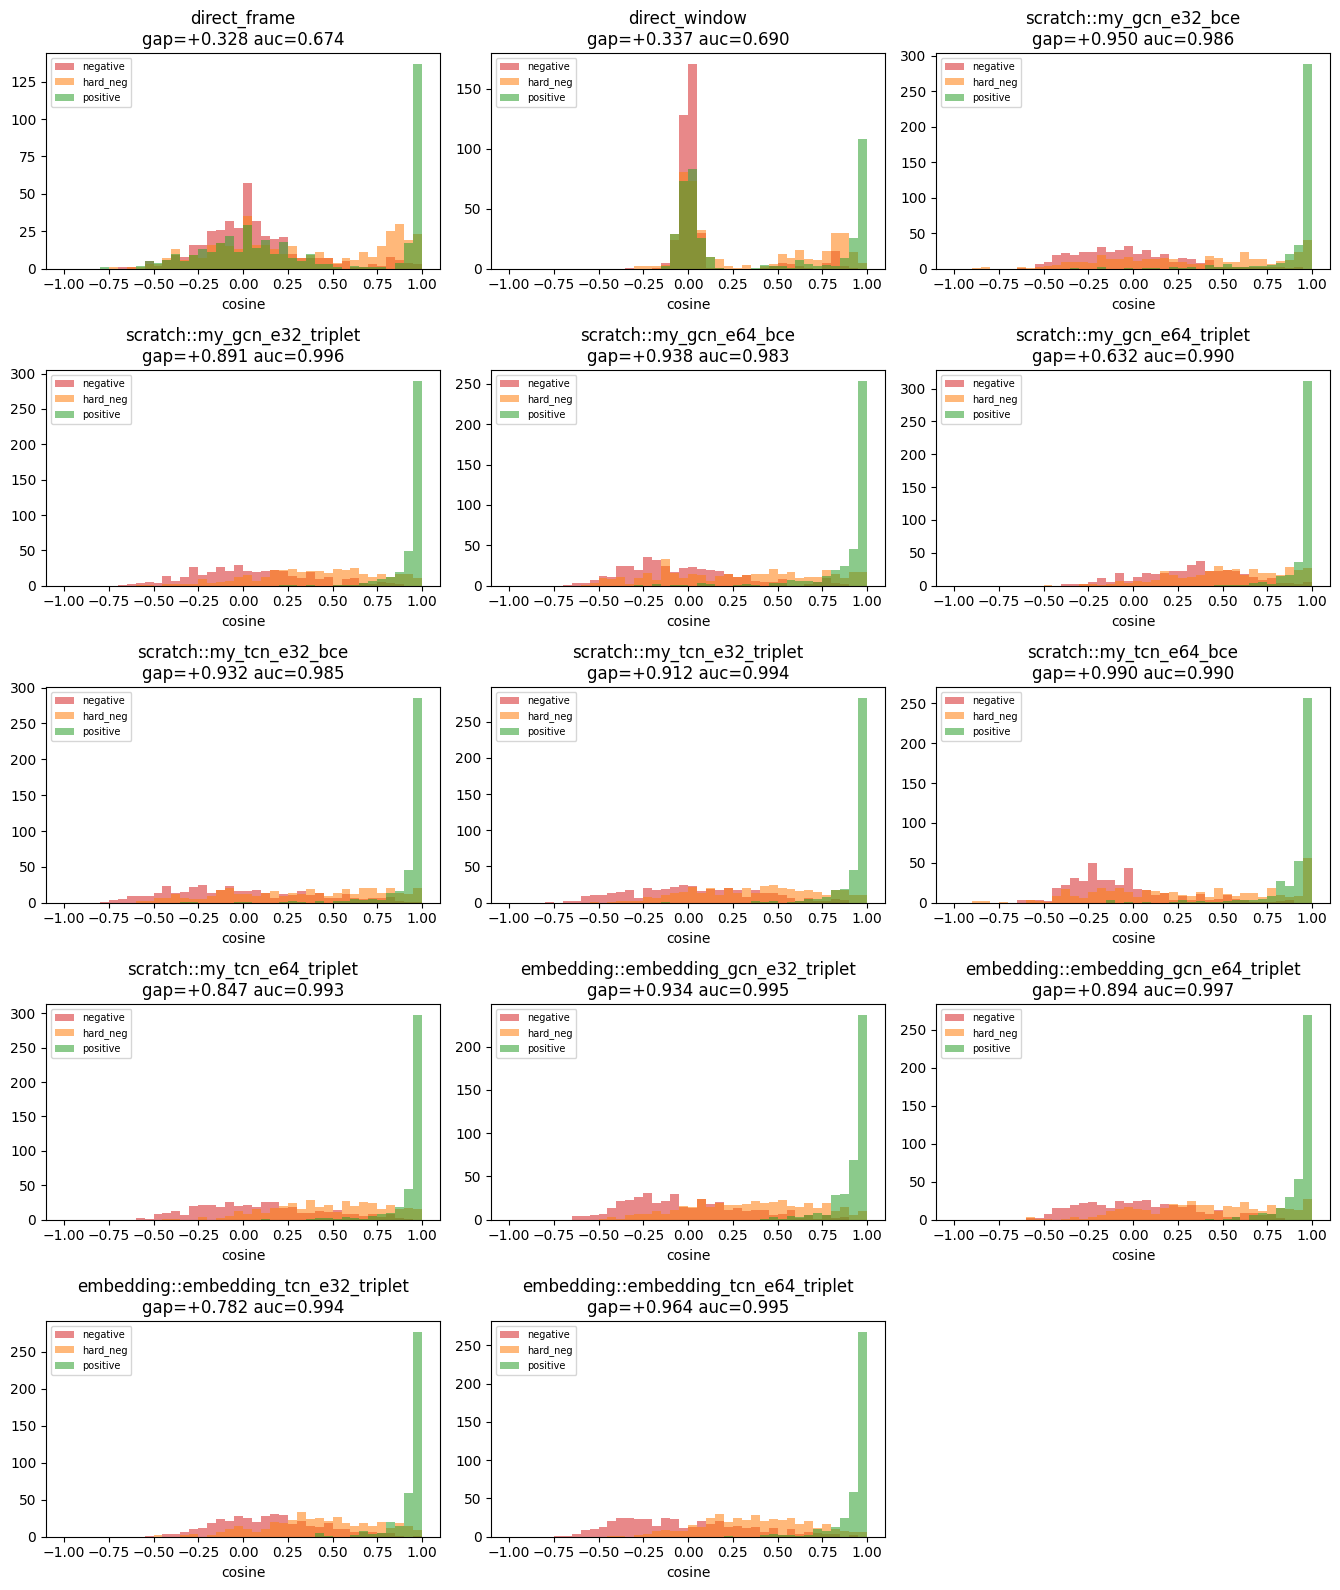

In [7]:
# --- Positive vs Negative cosine 분포 히스토그램 ---
n = len(results_pair)
cols = min(3, n)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4.5 * cols, 3.2 * rows), squeeze=False)
bins = np.linspace(-1.0, 1.0, 41)
for ax, (name, r) in zip(axes.ravel(), results_pair.items()):
    ax.hist(r['neg'], bins=bins, alpha=0.55, label='negative', color='tab:red')
    ax.hist(r['hneg'], bins=bins, alpha=0.55, label='hard_neg', color='tab:orange')
    ax.hist(r['pos'], bins=bins, alpha=0.55, label='positive', color='tab:green')
    ax.set_title(f"{name}\ngap={r['gap']:+.3f} auc={r['auc']:.3f}"
                 if r['auc'] is not None else
                 f"{name}\ngap={r['gap']:+.3f}")
    ax.set_xlabel('cosine')
    ax.legend(fontsize=7, loc='upper left')
for ax in axes.ravel()[len(results_pair):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 6. 지표 2 — Temporal Smoothness

**무엇을 보나**: embedding이 motion의 연속성을 보존하는가.

각 춤의 held-out 구간에서 stride=1로 연속된 window를 뽑아 `cos(E(t), E(t+k))` 를 계산한다. k가 작으면 embedding이 거의 같아야 하고 (cos ≈ 1), k가 커질수록 매끈하게 감소하는 게 좋은 embedding이다.

- k=1 (0.033s): 거의 동일한 자세 → 0.99 근처
- k=15 (0.5s): 동작이 조금 움직임 → 0.8~0.9
- k=120 (4s): 다른 구간일 가능성 → 많이 낮아짐

완전히 랜덤한 embedding은 k=1에서도 cos이 낮을 것. 학습이 실패한 신호.

In [8]:
def compute_temporal_smoothness(method):
    seq_length = method['seq_len']
    feat_dims = method.get('feat_dims', EVAL['default_feat_dims'])
    ks = EVAL['smoothness_ks']
    max_k = max(ks)

    per_k_cosines = {k: [] for k in ks}
    for d, seq in references.items():
        split = int(len(seq) * EVAL['train_ratio'])
        segment_lo = max(split, seq_length - 1)
        segment_hi = min(len(seq) - 1, segment_lo + EVAL['smoothness_segment_length'] - 1)
        if segment_hi - segment_lo < max_k + 1:
            continue
        ends = list(range(segment_lo, segment_hi + 1))
        embs = np.stack([
            method['embed'](make_window(d, e, seq_length, feat_dims))
            for e in ends
        ])  # (N, D), l2-normalized
        for k in ks:
            if len(embs) <= k:
                continue
            cos_k = (embs[:-k] * embs[k:]).sum(axis=-1)
            per_k_cosines[k].extend(cos_k.tolist())

    return {k: float(np.mean(per_k_cosines[k])) if per_k_cosines[k] else float('nan')
            for k in ks}


results_smooth = {}
for method in methods:
    results_smooth[method['name']] = compute_temporal_smoothness(method)
    row = results_smooth[method['name']]
    row_str = '  '.join(f'k={k}:{v:+.3f}' for k, v in row.items())
    print(f'  {method["name"]:30s}  {row_str}')

  direct_frame                    k=1:+0.327  k=5:+0.301  k=15:+0.266  k=30:+0.258  k=60:+0.230  k=120:+0.230
  direct_window                   k=1:+0.332  k=5:+0.303  k=15:+0.247  k=30:+0.251  k=60:+0.223  k=120:+0.215
  scratch::my_gcn_e32_bce         k=1:+0.979  k=5:+0.880  k=15:+0.661  k=30:+0.428  k=60:+0.305  k=120:+0.223
  scratch::my_gcn_e32_triplet     k=1:+0.986  k=5:+0.912  k=15:+0.718  k=30:+0.491  k=60:+0.350  k=120:+0.402
  scratch::my_gcn_e64_bce         k=1:+0.979  k=5:+0.840  k=15:+0.546  k=30:+0.309  k=60:+0.184  k=120:+0.264
  scratch::my_gcn_e64_triplet     k=1:+0.991  k=5:+0.918  k=15:+0.746  k=30:+0.579  k=60:+0.466  k=120:+0.416
  scratch::my_tcn_e32_bce         k=1:+0.981  k=5:+0.881  k=15:+0.595  k=30:+0.303  k=60:+0.252  k=120:+0.181
  scratch::my_tcn_e32_triplet     k=1:+0.984  k=5:+0.905  k=15:+0.675  k=30:+0.409  k=60:+0.330  k=120:+0.269
  scratch::my_tcn_e64_bce         k=1:+0.984  k=5:+0.866  k=15:+0.516  k=30:+0.368  k=60:+0.246  k=120:+0.152
  scratch:

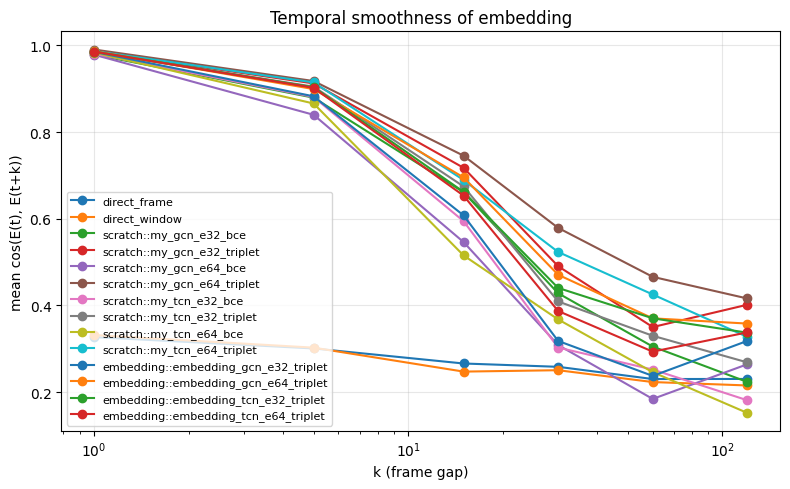

In [9]:
# --- Temporal decay curve ---
fig, ax = plt.subplots(figsize=(8, 5))
for name, row in results_smooth.items():
    ks = list(row.keys())
    vals = [row[k] for k in ks]
    ax.plot(ks, vals, marker='o', label=name)
ax.set_xlabel('k (frame gap)')
ax.set_ylabel('mean cos(E(t), E(t+k))')
ax.set_title('Temporal smoothness of embedding')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc='lower left')
plt.tight_layout()
plt.show()

## 7. 지표 3 — Noise Robustness

**무엇을 보나**: 실 서비스의 MediaPipe 출력에는 frame-wise jitter가 있다. 훈련 시 noise_std=0.015 정도가 첨가됐는데, embedding이 실제로 노이즈에 robust한지 더 다양한 σ에서 검증한다.

각 held-out window W에 대해:
1. `E_clean = embed(W)`
2. `E_noisy = embed(W + N(0, σ))`
3. `cos(E_clean, E_noisy)` 평균

좋은 embedding은 σ가 커져도 cos이 높게 유지된다. σ=0.05 (학습 σ의 3배)에서 0.9 이상이면 양호.

In [10]:
def compute_noise_robustness(method):
    seq_length = method['seq_len']
    feat_dims = method.get('feat_dims', EVAL['default_feat_dims'])
    sigmas = EVAL['noise_sigmas']

    # 로컬 rng — method마다 같은 window/같은 noise pattern 사용
    local_rng = np.random.default_rng(EVAL['seed'] + 999)

    dances = list(references.keys())
    per_dance = max(1, EVAL['n_noise_windows'] // len(dances) + 1)
    samples = []
    for d in dances:
        er = valid_eval_end_range(d, seq_length)
        if er is None:
            continue
        lo, hi = er
        for _ in range(per_dance):
            end = int(local_rng.integers(lo, hi + 1))
            samples.append(make_window(d, end, seq_length, feat_dims))
    samples = samples[:EVAL['n_noise_windows']]

    e_clean = np.stack([method['embed'](w) for w in samples])  # (N, D)

    result = {}
    for sigma in sigmas:
        cos_list = []
        for i, w in enumerate(samples):
            noise_rng = np.random.default_rng(EVAL['seed'] + 10000 + i)
            w_noisy = w + noise_rng.normal(0.0, sigma, w.shape).astype(np.float32)
            e_noisy = method['embed'](w_noisy)
            cos_list.append(float(np.dot(e_clean[i], e_noisy)))
        result[sigma] = float(np.mean(cos_list))
    return result


results_noise = {}
for method in methods:
    results_noise[method['name']] = compute_noise_robustness(method)
    row = results_noise[method['name']]
    row_str = '  '.join(f'σ={s:.2f}:{v:+.3f}' for s, v in row.items())
    print(f'  {method["name"]:30s}  {row_str}')

  direct_frame                    σ=0.01:+1.000  σ=0.03:+0.999  σ=0.05:+0.998  σ=0.10:+0.991
  direct_window                   σ=0.01:+1.000  σ=0.03:+1.000  σ=0.05:+0.999  σ=0.10:+0.995
  scratch::my_gcn_e32_bce         σ=0.01:+1.000  σ=0.03:+1.000  σ=0.05:+0.999  σ=0.10:+0.998
  scratch::my_gcn_e32_triplet     σ=0.01:+1.000  σ=0.03:+1.000  σ=0.05:+0.999  σ=0.10:+0.997
  scratch::my_gcn_e64_bce         σ=0.01:+1.000  σ=0.03:+1.000  σ=0.05:+0.999  σ=0.10:+0.998
  scratch::my_gcn_e64_triplet     σ=0.01:+1.000  σ=0.03:+1.000  σ=0.05:+1.000  σ=0.10:+0.998
  scratch::my_tcn_e32_bce         σ=0.01:+1.000  σ=0.03:+1.000  σ=0.05:+0.999  σ=0.10:+0.998
  scratch::my_tcn_e32_triplet     σ=0.01:+1.000  σ=0.03:+1.000  σ=0.05:+0.999  σ=0.10:+0.998
  scratch::my_tcn_e64_bce         σ=0.01:+1.000  σ=0.03:+1.000  σ=0.05:+1.000  σ=0.10:+0.998
  scratch::my_tcn_e64_triplet     σ=0.01:+1.000  σ=0.03:+1.000  σ=0.05:+1.000  σ=0.10:+0.999
  embedding::embedding_gcn_e32_triplet  σ=0.01:+1.000  σ=0.03:+1.000  

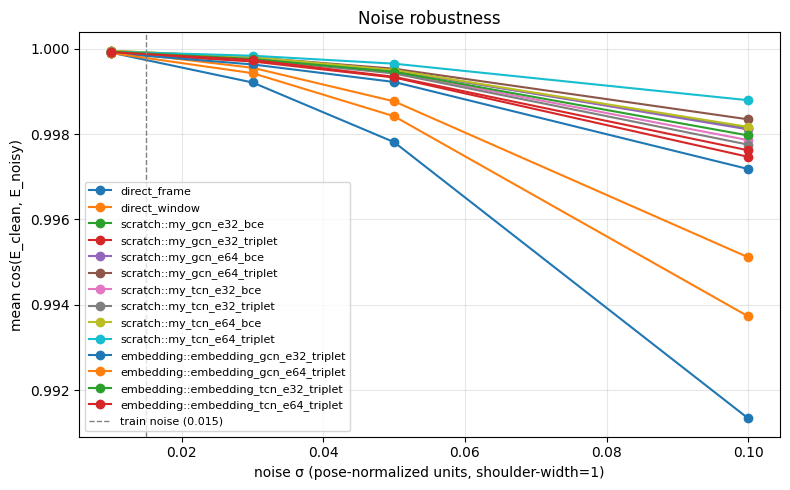

In [11]:
# --- Noise robustness curve ---
fig, ax = plt.subplots(figsize=(8, 5))
for name, row in results_noise.items():
    sigmas = list(row.keys())
    vals = [row[s] for s in sigmas]
    ax.plot(sigmas, vals, marker='o', label=name)
ax.axvline(0.015, color='gray', linestyle='--', linewidth=1, label='train noise (0.015)')
ax.set_xlabel('noise σ (pose-normalized units, shoulder-width=1)')
ax.set_ylabel('mean cos(E_clean, E_noisy)')
ax.set_title('Noise robustness')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc='lower left')
plt.tight_layout()
plt.show()

## 8. 지표 4 — Top-1 Retrieval (참고용)

**참고 지표**: 각 held-out query window에 대해 "5개 춤 중 어느 것인가" 를 per-dance max cosine 으로 맞힌다. 1에 가까울수록 좋음. pair discrimination이 충분히 좋으면 자동으로 top-1도 높게 나오므로 이중 확인용.

In [12]:
def compute_top1(method):
    seq_length = method['seq_len']
    feat_dims = method.get('feat_dims', EVAL['default_feat_dims'])
    dances = list(references.keys())

    gallery_emb, query_emb = {}, {}
    for d, seq in references.items():
        split = int(len(seq) * EVAL['train_ratio'])
        g_ends = list(range(seq_length - 1, split, EVAL['retrieval_gallery_stride']))
        q_ends = list(range(split + seq_length - 1, len(seq), EVAL['retrieval_query_stride']))
        gallery_emb[d] = (np.stack([method['embed'](make_window(d, e, seq_length, feat_dims))
                                    for e in g_ends])
                          if g_ends else None)
        query_emb[d] = (np.stack([method['embed'](make_window(d, e, seq_length, feat_dims))
                                  for e in q_ends])
                        if q_ends else None)

    n_correct, n_total = 0, 0
    for true_d in dances:
        queries = query_emb[true_d]
        if queries is None or len(queries) == 0:
            continue
        per_dance_max = []
        for cand_d in dances:
            gallery = gallery_emb[cand_d]
            if gallery is None or len(gallery) == 0:
                per_dance_max.append(np.full(len(queries), -np.inf))
            else:
                sims = queries @ gallery.T
                per_dance_max.append(sims.max(axis=1))
        stacked = np.stack(per_dance_max, axis=1)  # (Q, n_dances)
        preds = stacked.argmax(axis=1)
        true_idx = dances.index(true_d)
        n_correct += int((preds == true_idx).sum())
        n_total += len(queries)
    return n_correct / max(1, n_total)


results_top1 = {}
for method in methods:
    results_top1[method['name']] = compute_top1(method)
    print(f'  {method["name"]:30s}  top-1 = {results_top1[method["name"]]:.3f}')

  direct_frame                    top-1 = 0.409
  direct_window                   top-1 = 0.435
  scratch::my_gcn_e32_bce         top-1 = 0.489
  scratch::my_gcn_e32_triplet     top-1 = 0.398
  scratch::my_gcn_e64_bce         top-1 = 0.360
  scratch::my_gcn_e64_triplet     top-1 = 0.344
  scratch::my_tcn_e32_bce         top-1 = 0.339
  scratch::my_tcn_e32_triplet     top-1 = 0.414
  scratch::my_tcn_e64_bce         top-1 = 0.360
  scratch::my_tcn_e64_triplet     top-1 = 0.333
  embedding::embedding_gcn_e32_triplet  top-1 = 0.392
  embedding::embedding_gcn_e64_triplet  top-1 = 0.478
  embedding::embedding_tcn_e32_triplet  top-1 = 0.392
  embedding::embedding_tcn_e64_triplet  top-1 = 0.446


## 9. 지표 5 — 서비스 지향 평가

위 지표들은 embedding 표현 자체의 품질을 본다. 아래 지표들은 실제 gameplay scoring loop에 더 가깝다.

1. **Within-song localization**: 같은 춤 안에서 query window가 reference timeline의 실제 시간 근처를 nearest neighbor로 찾는가.
2. **Delay/tolerance curve**: 게임처럼 `[t-delay, t]` 후보 window 중 top-k 평균을 썼을 때 정확한 동작과 틀린 동작의 점수 차이가 얼마나 나는가.
3. **Positive jitter curve**: query time과 reference time이 조금씩 어긋날 때 cosine이 얼마나 자연스럽게 낮아지는가.
4. **Score calibration**: positive/negative/hard-negative cosine percentile을 보고 threshold와 점수 해상도를 가늠한다.

이 네 지표는 `embedding` 모델이 실제 서비스에서 정확하고 안정적인 유사도 점수를 만들 수 있는지 판단하는 데 더 직접적이다.


In [13]:
# --- Service metric 1: within-song localization ---
def compute_within_song_localization(method):
    seq_length = method['seq_len']
    feat_dims = method.get('feat_dims', EVAL['default_feat_dims'])
    tolerances = EVAL['localization_tolerance_frames']
    result = {tol: [] for tol in tolerances}
    median_errors = []

    for dance, seq in references.items():
        split = int(len(seq) * EVAL['train_ratio'])
        eval_lo = max(split + seq_length - 1, seq_length - 1)
        eval_hi = len(seq) - 1
        if eval_lo > eval_hi:
            continue

        gallery_ends = np.arange(seq_length - 1, len(seq), EVAL['localization_gallery_stride'], dtype=int)
        query_ends = np.arange(eval_lo, eval_hi + 1, EVAL['localization_query_stride'], dtype=int)
        if len(gallery_ends) == 0 or len(query_ends) == 0:
            continue

        gallery_embs = np.stack([
            method['embed'](make_window(dance, int(end), seq_length, feat_dims))
            for end in gallery_ends
        ])
        query_embs = np.stack([
            method['embed'](make_window(dance, int(end), seq_length, feat_dims))
            for end in query_ends
        ])
        sims = query_embs @ gallery_embs.T
        nearest = gallery_ends[np.argmax(sims, axis=1)]
        errors = np.abs(nearest - query_ends)
        median_errors.extend(errors.tolist())
        for tol in tolerances:
            result[tol].extend((errors <= tol).astype(np.float32).tolist())

    out = {f'loc@{tol}f': float(np.mean(vals)) if vals else float('nan')
           for tol, vals in result.items()}
    out['median_error_frames'] = float(np.median(median_errors)) if median_errors else float('nan')
    return out


results_localization = {}
for method in methods:
    results_localization[method['name']] = compute_within_song_localization(method)
    row = results_localization[method['name']]
    acc_str = '  '.join(
        f'{k}:{v:.3f}' for k, v in row.items() if k.startswith('loc@')
    )
    print(f'  {method["name"]:45s}  median_err={row["median_error_frames"]:.1f}f  {acc_str}')


  direct_frame                                   median_err=0.0f  loc@3f:0.683  loc@6f:0.688  loc@15f:0.694  loc@30f:0.704
  direct_window                                  median_err=0.0f  loc@3f:0.715  loc@6f:0.715  loc@15f:0.726  loc@30f:0.726
  scratch::my_gcn_e32_bce                        median_err=0.0f  loc@3f:0.984  loc@6f:0.995  loc@15f:1.000  loc@30f:1.000
  scratch::my_gcn_e32_triplet                    median_err=0.0f  loc@3f:1.000  loc@6f:1.000  loc@15f:1.000  loc@30f:1.000
  scratch::my_gcn_e64_bce                        median_err=0.0f  loc@3f:0.973  loc@6f:0.989  loc@15f:0.989  loc@30f:0.989
  scratch::my_gcn_e64_triplet                    median_err=0.0f  loc@3f:0.978  loc@6f:0.989  loc@15f:1.000  loc@30f:1.000
  scratch::my_tcn_e32_bce                        median_err=0.0f  loc@3f:0.995  loc@6f:1.000  loc@15f:1.000  loc@30f:1.000
  scratch::my_tcn_e32_triplet                    median_err=0.0f  loc@3f:0.995  loc@6f:1.000  loc@15f:1.000  loc@30f:1.000
  scratch::my_tc

In [14]:
# --- Service metric 2: delay/tolerance scoring curve ---
def candidate_indices(end_idx, total_frames, seq_length, tolerance_frames, stride):
    end = min(int(end_idx), int(total_frames) - 1)
    if end < seq_length - 1:
        return []
    start = max(seq_length - 1, end - int(tolerance_frames))
    indices = list(range(start, end + 1, max(1, int(stride))))
    if indices and indices[-1] != end:
        indices.append(end)
    return indices


def topk_reference_score(method, query_dance, query_end, reference_dance, reference_end, tolerance_frames):
    seq_length = method['seq_len']
    feat_dims = method.get('feat_dims', EVAL['default_feat_dims'])
    q_emb = method['embed'](make_window(query_dance, query_end, seq_length, feat_dims))
    candidates = candidate_indices(
        reference_end,
        len(references[reference_dance]),
        seq_length,
        tolerance_frames,
        EVAL['retrieval_gallery_stride'],
    )
    if not candidates:
        return float('nan')
    sims = []
    for end in candidates:
        r_emb = method['embed'](make_window(reference_dance, end, seq_length, feat_dims))
        sims.append(float(np.dot(q_emb, r_emb)))
    sims = sorted(sims, reverse=True)
    k = min(EVAL['delay_top_k'], len(sims))
    return float(np.mean(sims[:k]))


def compute_delay_curve(method):
    seq_length = method['seq_len']
    delays = EVAL['delay_tolerance_frames']
    local_rng = np.random.default_rng(EVAL['seed'] + 202)
    dances = list(references.keys())
    result = {delay: {'same': [], 'wrong': [], 'hard': []} for delay in delays}

    samples = []
    for dance in dances:
        er = valid_eval_end_range(dance, seq_length)
        if er is None:
            continue
        lo, hi = er
        for _ in range(EVAL['n_pairs_per_dance']):
            end = int(local_rng.integers(lo, hi + 1))
            samples.append((dance, end))

    for dance, end in samples:
        other = str(local_rng.choice([d for d in dances if d != dance]))
        other_er = valid_eval_end_range(other, seq_length)
        if other_er is None:
            continue
        other_end = int(local_rng.integers(other_er[0], other_er[1] + 1))
        hard_end = int(np.clip(end + EVAL['negative_gap'], seq_length - 1, len(references[dance]) - 1))
        if abs(hard_end - end) < EVAL['negative_gap']:
            hard_end = int(np.clip(end - EVAL['negative_gap'], seq_length - 1, len(references[dance]) - 1))

        for delay in delays:
            result[delay]['same'].append(topk_reference_score(method, dance, end, dance, end, delay))
            result[delay]['wrong'].append(topk_reference_score(method, dance, end, other, other_end, delay))
            result[delay]['hard'].append(topk_reference_score(method, dance, end, dance, hard_end, delay))

    out = {}
    for delay, buckets in result.items():
        same = np.asarray(buckets['same'], dtype=np.float32)
        wrong = np.asarray(buckets['wrong'], dtype=np.float32)
        hard = np.asarray(buckets['hard'], dtype=np.float32)
        out[delay] = {
            'same': float(np.nanmean(same)),
            'wrong': float(np.nanmean(wrong)),
            'hard': float(np.nanmean(hard)),
            'gap_wrong': float(np.nanmean(same) - np.nanmean(wrong)),
            'gap_hard': float(np.nanmean(same) - np.nanmean(hard)),
        }
    return out


results_delay = {}
for method in methods:
    results_delay[method['name']] = compute_delay_curve(method)
    row = results_delay[method['name']]
    summary_delay = 30 if 30 in row else max(row)
    r = row[summary_delay]
    print(f'  {method["name"]:45s}  delay={summary_delay}f  '
          f'same={r["same"]:+.3f} wrong={r["wrong"]:+.3f} hard={r["hard"]:+.3f} '
          f'gap_wrong={r["gap_wrong"]:+.3f} gap_hard={r["gap_hard"]:+.3f}')


  direct_frame                                   delay=30f  same=+0.635 wrong=+0.214 hard=+0.419 gap_wrong=+0.421 gap_hard=+0.217
  direct_window                                  delay=30f  same=+0.570 wrong=+0.118 hard=+0.286 gap_wrong=+0.452 gap_hard=+0.284


KeyboardInterrupt: 

In [ ]:
# --- Delay/tolerance curve plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
for name, curve in results_delay.items():
    delays = sorted(curve.keys())
    axes[0].plot(delays, [curve[d]['same'] for d in delays], marker='o', label=f'{name} same')
    axes[0].plot(delays, [curve[d]['wrong'] for d in delays], marker='x', linestyle='--', label=f'{name} wrong')
    axes[1].plot(delays, [curve[d]['gap_wrong'] for d in delays], marker='o', label=name)
axes[0].set_title('Top-k service score: same vs wrong dance')
axes[0].set_ylabel('mean top-k cosine')
axes[1].set_title('Service score gap by tolerance')
axes[1].set_ylabel('same - wrong')
for ax in axes:
    ax.set_xlabel('tolerance frames')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='best')
plt.tight_layout()
plt.show()


In [ ]:
# --- Service metric 3: positive jitter curve ---
def compute_jitter_curve(method):
    seq_length = method['seq_len']
    feat_dims = method.get('feat_dims', EVAL['default_feat_dims'])
    jitters = EVAL['jitter_frames']
    local_rng = np.random.default_rng(EVAL['seed'] + 303)
    result = {j: [] for j in jitters}

    for dance, seq in references.items():
        er = valid_eval_end_range(dance, seq_length)
        if er is None:
            continue
        lo, hi = er
        for _ in range(EVAL['n_pairs_per_dance']):
            end = int(local_rng.integers(lo, hi + 1))
            emb = method['embed'](make_window(dance, end, seq_length, feat_dims))
            for jitter in jitters:
                compare_end = int(np.clip(end + jitter, seq_length - 1, len(seq) - 1))
                other_emb = method['embed'](make_window(dance, compare_end, seq_length, feat_dims))
                result[jitter].append(float(np.dot(emb, other_emb)))
    return {j: float(np.mean(vals)) if vals else float('nan') for j, vals in result.items()}


results_jitter = {}
for method in methods:
    results_jitter[method['name']] = compute_jitter_curve(method)
    row = results_jitter[method['name']]
    row_str = '  '.join(f'±{j}f:{v:+.3f}' for j, v in row.items())
    print(f'  {method["name"]:45s}  {row_str}')

fig, ax = plt.subplots(figsize=(9, 5))
for name, row in results_jitter.items():
    js = list(row.keys())
    vals = [row[j] for j in js]
    ax.plot(js, vals, marker='o', label=name)
ax.set_xlabel('positive time offset (frames)')
ax.set_ylabel('mean cosine')
ax.set_title('Positive jitter curve')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7, loc='best')
plt.tight_layout()
plt.show()


In [ ]:
# --- Service metric 4: score calibration percentiles ---
def pct(arr, q):
    return float(np.percentile(np.asarray(arr, dtype=np.float32), q)) if len(arr) else float('nan')

results_calibration = {}
for name, r in results_pair.items():
    pos = r['pos']
    neg = r['neg']
    hneg = r['hneg']
    results_calibration[name] = {
        'pos_p05': pct(pos, 5),
        'pos_p50': pct(pos, 50),
        'pos_p95': pct(pos, 95),
        'neg_p50': pct(neg, 50),
        'neg_p95': pct(neg, 95),
        'hneg_p50': pct(hneg, 50),
        'hneg_p95': pct(hneg, 95),
        'suggested_threshold_mid': float((pct(pos, 5) + max(pct(neg, 95), pct(hneg, 95))) * 0.5),
    }

header = f'{"METHOD":45s}  {"pos_p05":>8s} {"pos_p50":>8s} {"neg_p95":>8s} {"hneg_p95":>9s} {"thr_mid":>8s}'
print(header)
print('-' * len(header))
for method in methods:
    name = method['name']
    c = results_calibration[name]
    print(f'{name:45s}  {c["pos_p05"]:+8.3f} {c["pos_p50"]:+8.3f} '
          f'{c["neg_p95"]:+8.3f} {c["hneg_p95"]:+9.3f} {c["suggested_threshold_mid"]:+8.3f}')


## 10. 종합 표

모든 지표를 한 표로 모아 비교한다. `GAP/AUC`는 표현 공간의 기본 분리력이고, `LOC@15F`, `DELAY_GAP`, `JITTER_30`, `THR_MID`는 실제 서비스 scoring 관점의 지표다.


In [ ]:
header_cols = [
    ('METHOD', 45),
    ('LOSS', 8),
    ('POS', 7),
    ('NEG', 7),
    ('HARD', 7),
    ('GAP', 8),
    ('AUC', 6),
    ('SMOOTH_15', 10),
    ('NOISE_0.05', 11),
    ('TOP-1', 6),
    ('LOC@15F', 8),
    ('MED_ERR', 8),
    ('DELAY_GAP', 10),
    ('JITTER_30', 10),
    ('THR_MID', 8),
]
header = '  '.join(f'{col:>{w}s}' if col != 'METHOD' else f'{col:<{w}s}'
                   for col, w in header_cols)
print(header)
print('-' * (sum(w for _, w in header_cols) + 2 * (len(header_cols) - 1)))

rows = []
for method in methods:
    name = method['name']
    r1 = results_pair[name]
    smooth = results_smooth[name].get(15, float('nan'))
    noise = results_noise[name].get(0.05, float('nan'))
    t1 = results_top1[name]
    loc = results_localization.get(name, {}).get('loc@15f', float('nan'))
    med_err = results_localization.get(name, {}).get('median_error_frames', float('nan'))
    delay_curve = results_delay.get(name, {})
    delay_key = 30 if 30 in delay_curve else (max(delay_curve) if delay_curve else None)
    delay_gap = delay_curve.get(delay_key, {}).get('gap_wrong', float('nan')) if delay_key is not None else float('nan')
    jitter_30 = results_jitter.get(name, {}).get(30, float('nan'))
    thr_mid = results_calibration.get(name, {}).get('suggested_threshold_mid', float('nan'))
    auc_val = r1['auc']
    auc_str = f'{auc_val:.3f}' if (auc_val is not None and np.isfinite(auc_val)) else '  -  '
    row_vals = [
        f'{name:<45s}',
        f'{method["loss"]:>8s}',
        f'{r1["mean_pos"]:>+7.3f}',
        f'{r1["mean_neg"]:>+7.3f}',
        f'{r1["mean_hneg"]:>+7.3f}',
        f'{r1["gap"]:>+8.3f}',
        f'{auc_str:>6s}',
        f'{smooth:>+10.3f}',
        f'{noise:>+11.3f}',
        f'{t1:>6.3f}',
        f'{loc:>8.3f}',
        f'{med_err:>8.1f}',
        f'{delay_gap:>+10.3f}',
        f'{jitter_30:>+10.3f}',
        f'{thr_mid:>+8.3f}',
    ]
    print('  '.join(row_vals))
    rows.append({
        'name': name, 'loss': method['loss'],
        'pos': r1['mean_pos'], 'neg': r1['mean_neg'], 'hard_neg': r1['mean_hneg'],
        'gap': r1['gap'], 'auc': auc_val,
        'smooth_15': smooth, 'noise_05': noise, 'top1': t1,
        'loc_15': loc, 'median_error_frames': med_err,
        'delay_gap_30': delay_gap, 'jitter_30': jitter_30, 'threshold_mid': thr_mid,
    })

model_rows = [r for r in rows if not r['name'].startswith('direct_')]
if model_rows:
    print()
    def best_by(key, reverse=True):
        return max(model_rows, key=lambda r: r[key] if (r[key] is not None and np.isfinite(r[key])) else -np.inf) if reverse \
               else min(model_rows, key=lambda r: r[key] if (r[key] is not None and np.isfinite(r[key])) else np.inf)
    print(f'[BEST by gap]         {best_by("gap")["name"]}  ({best_by("gap")["gap"]:+.3f})')
    if any(r['auc'] is not None and np.isfinite(r['auc']) for r in model_rows):
        print(f'[BEST by auc]         {best_by("auc")["name"]}  ({best_by("auc")["auc"]:.3f})')
    print(f'[BEST by loc@15f]     {best_by("loc_15")["name"]}  ({best_by("loc_15")["loc_15"]:.3f})')
    print(f'[BEST by med error]   {best_by("median_error_frames", reverse=False)["name"]}  '
          f'({best_by("median_error_frames", reverse=False)["median_error_frames"]:.1f}f)')
    print(f'[BEST by delay gap]   {best_by("delay_gap_30")["name"]}  ({best_by("delay_gap_30")["delay_gap_30"]:+.3f})')
    print(f'[BEST by noise rob.]  {best_by("noise_05")["name"]}  ({best_by("noise_05")["noise_05"]:+.3f})')
    print(f'[BEST by top-1]       {best_by("top1")["name"]}  ({best_by("top1")["top1"]:.3f})')


## 11. 해석 가이드

- **`GAP`이 클수록** pair 수준에서 같은 동작과 다른 동작이 확실히 벌어진다 → 서비스에서 점수 해상도가 높다.
- **`AUC`가 1에 가까울수록** cosine threshold를 어디에 잡든 분류가 잘 된다 → tolerance 파라미터에 덜 민감하다.
- **`HARD_NEG`가 `POS`와 비슷하면** 모델이 같은 춤 내부 다른 구간을 구분하지 못한다. 게임에서 아무 포즈나 취해도 점수가 나오는 리스크가 있다.
- **`SMOOTH_15`이 너무 낮으면** 0.5초 이웃 window가 지나치게 다르게 보인다는 뜻이다 → 점수가 튈 수 있다.
- **`NOISE_0.05`가 낮으면** MediaPipe jitter만으로 embedding이 흔들릴 수 있다.

비교 관점:

1. `direct_*`보다 `scratch::*` 또는 `embedding::*`의 GAP/AUC가 의미 있게 좋아야 모델을 쓸 이유가 있다.
2. `embedding::*`가 `scratch::*`보다 좋아지면 MPOSE2021 pretraining + dance fine-tuning이 효과를 낸 것이다.
3. `embedding::*`가 `scratch::*`보다 낮다면 현재 dance fine-tuning 데이터가 부족하거나, MPOSE pretraining domain이 서비스 목표와 잘 맞지 않는 것이다.
4. 최종 후보는 GAP/AUC만 보지 말고 `NOISE_0.05`, `SMOOTH_15`도 같이 봐야 한다.

이 노트북은 정량 비교용이고, 최종 후보는 `embedding_finetuning.ipynb`의 애니메이션/유사도 확인과 실제 gameplay 점수 안정성까지 함께 보고 고르는 것이 좋다.
